# Employee Attrition Analysis

### Exploratory Data Analysis of Employee Attrition, Job Roles and Workplace Factors

## 1. Introduction

Employee attrition is an important business issue because employee turnover can affect workforce stability and recruitment requirements.

In this project, Exploratory Data Analysis (EDA) is performed on employee data to identify patterns related to attrition.

The analysis focuses on departments, job roles, overtime, job satisfaction, monthly income and years at the company.

## 2. Business Problem

Organizations need to understand employee attrition patterns in order to identify areas that may require attention.

This analysis compares employees who stayed and those who left using job roles, departments, overtime, job satisfaction, monthly income and years at the company.

The objective is to identify descriptive patterns in the dataset rather than predict individual employee attrition.

## 3. Objectives

- Understand the structure of the employee dataset
- Check missing values and duplicate records
- Perform basic data cleaning
- Analyze overall employee attrition
- Compare attrition across departments and job roles
- Analyze overtime and job satisfaction
- Compare monthly income and years at the company
- Examine the relationship between income and tenure
- Generate useful business insights

## 4. Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 5. Load Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Data Analytics/IBM_HR-Employee-Attrition.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 6. Data Understanding

The dataset contains 1,470 employee records and 35 columns containing demographic, job-related and workplace information.

In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

df.info()

Shape: (1470, 35)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber           

## 7. Missing Value Analysis

Missing values were checked across all columns. The dataset contains no missing values, so no imputation was required.

In [ ]:
missing_values = df.isnull().sum()

print("Total Missing Values:", missing_values.sum())

Total Missing Values: 0


## 8. Duplicate Analysis

Duplicate records were checked to ensure that repeated employee records do not affect the analysis.

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 9. Data Cleaning

Columns containing constant values or employee identification information were removed because they do not provide meaningful variation for the selected EDA.

In [ ]:
df = df.drop(columns=[
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
])

df.shape

(1470, 31)

## 10. Descriptive Statistics

Descriptive statistics were used to understand the numerical characteristics of employee income and company tenure.

Measures such as mean, median, minimum and maximum values were examined.

In [ ]:
df[['MonthlyIncome',
    'YearsAtCompany']].describe()

,MonthlyIncome,YearsAtCompany
count,1470.000000,1470.000000
mean,6502.931293,7.008163
std,4707.956783,6.126525
min,1009.000000,0.000000
25%,2911.000000,3.000000
50%,4919.000000,5.000000
75%,8379.000000,9.000000
max,19999.000000,40.000000


## 11. Overall Employee Attrition

The overall distribution of employee attrition was analyzed to understand the proportion of employees who stayed with the organization and those who left.

This provides a baseline for comparing attrition across different employee groups.

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentage:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


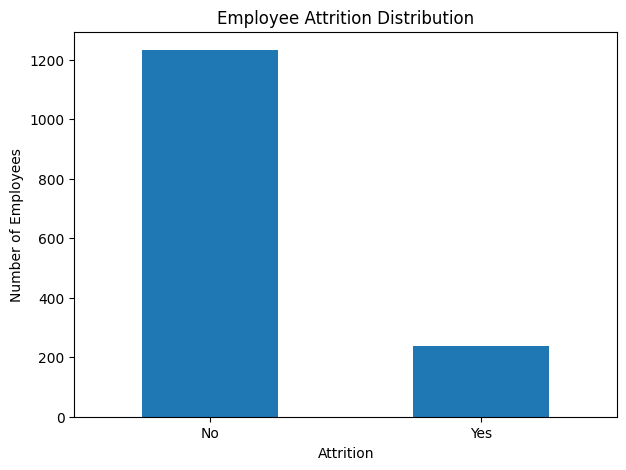

In [ ]:
attrition_count = df['Attrition'].value_counts()

print(attrition_count)

attrition_percentage = df['Attrition'].value_counts(normalize=True) * 100

print("\nAttrition Percentage:")
print(attrition_percentage.round(2))

attrition_count.plot(
    kind='bar',
    figsize=(7,5),
    title='Employee Attrition Distribution'
)

plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.show()

## 12. Attrition by Department

Employee attrition was compared across departments using percentages to account for differences in department size.

Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


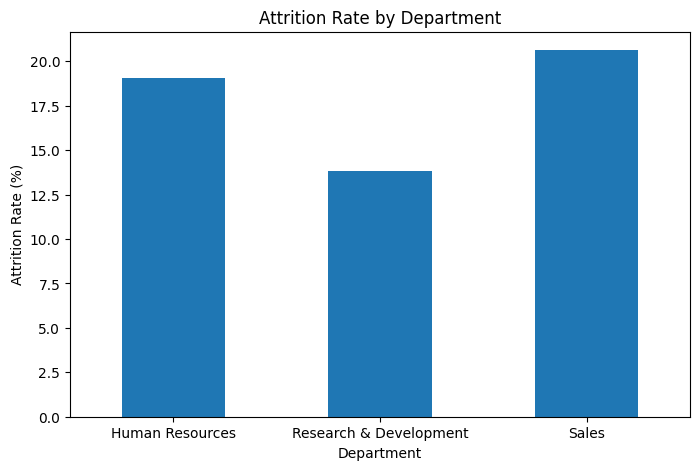

In [ ]:
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

print(department_attrition.round(2))

department_attrition['Yes'].plot(
    kind='bar',
    figsize=(8,5),
    title='Attrition Rate by Department'
)

plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

## 13. Attrition by Job Role

Attrition rates were compared across different job roles to identify differences in employee turnover patterns.

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Yes, dtype: float64


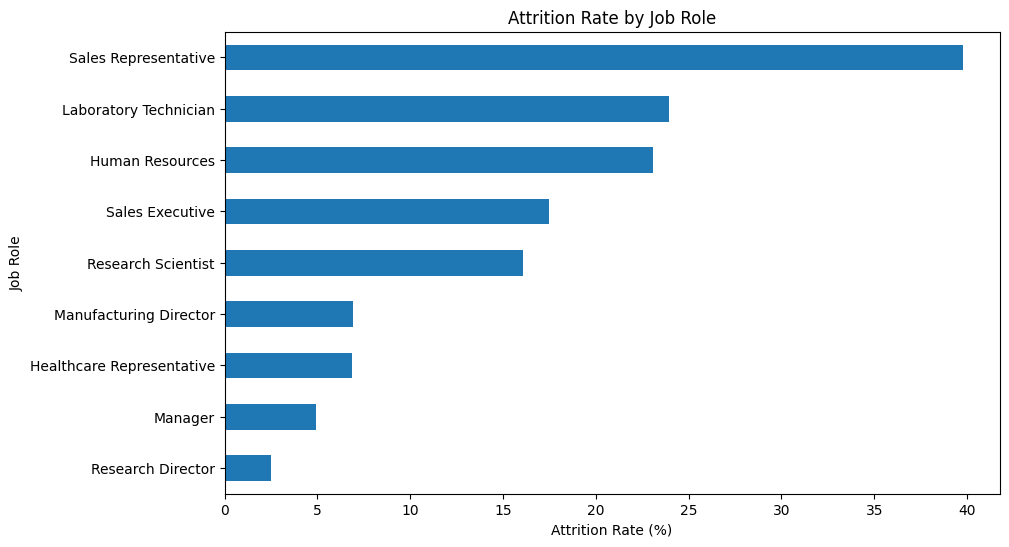

In [ ]:
role_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

print(role_attrition['Yes'].sort_values(ascending=False).round(2))

role_attrition['Yes'].sort_values().plot(
    kind='barh',
    figsize=(10,6),
    title='Attrition Rate by Job Role'
)

plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.show()

## 14. Overtime and Attrition

The relationship between overtime status and employee attrition was examined by comparing attrition percentages for employees who work overtime and those who do not.

Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53


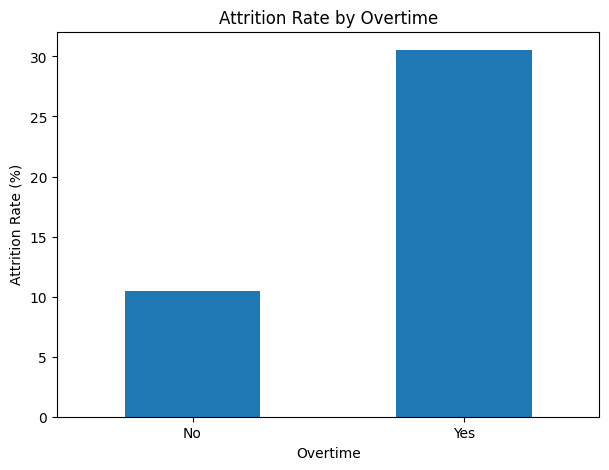

In [ ]:
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

print(overtime_attrition.round(2))

overtime_attrition['Yes'].plot(
    kind='bar',
    figsize=(7,5),
    title='Attrition Rate by Overtime'
)

plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

## 15. Job Satisfaction and Attrition

Attrition was compared across the four job satisfaction levels to identify differences in employee attrition patterns.

Attrition           No    Yes
JobSatisfaction              
1                77.16  22.84
2                83.57  16.43
3                83.48  16.52
4                88.67  11.33


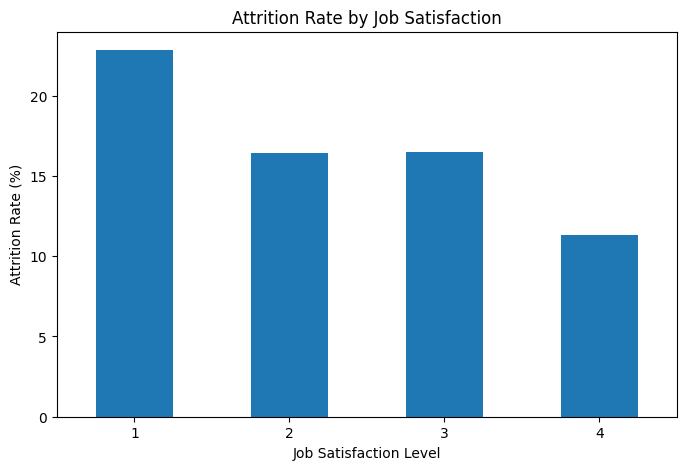

In [ ]:
satisfaction_attrition = pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100

print(satisfaction_attrition.round(2))

satisfaction_attrition['Yes'].plot(
    kind='bar',
    figsize=(8,5),
    title='Attrition Rate by Job Satisfaction'
)

plt.xlabel('Job Satisfaction Level')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

## 16. Monthly Income and Attrition

Average monthly income was compared between employees who stayed and employees who left.

The comparison provides a descriptive view of income differences between the two attrition groups.

Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64


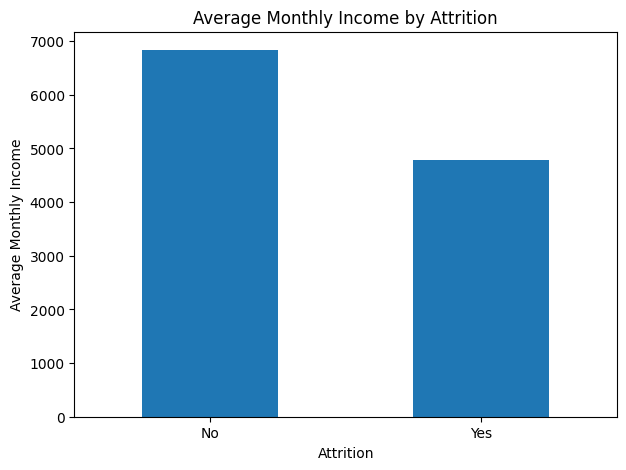

In [ ]:
income_attrition = df.groupby('Attrition')['MonthlyIncome'].mean()

print(income_attrition.round(2))

income_attrition.plot(
    kind='bar',
    figsize=(7,5),
    title='Average Monthly Income by Attrition'
)

plt.xlabel('Attrition')
plt.ylabel('Average Monthly Income')
plt.xticks(rotation=0)
plt.show()

## 17. Years at Company and Attrition

Employee attrition was analyzed across different tenure groups to compare attrition patterns among employees with different years of experience in the organization.

Attrition       No    Yes
TenureGroup              
0-2          70.18  29.82
3-5          86.18  13.82
6-10         87.72  12.28
11-20        93.33   6.67
20+          87.88  12.12


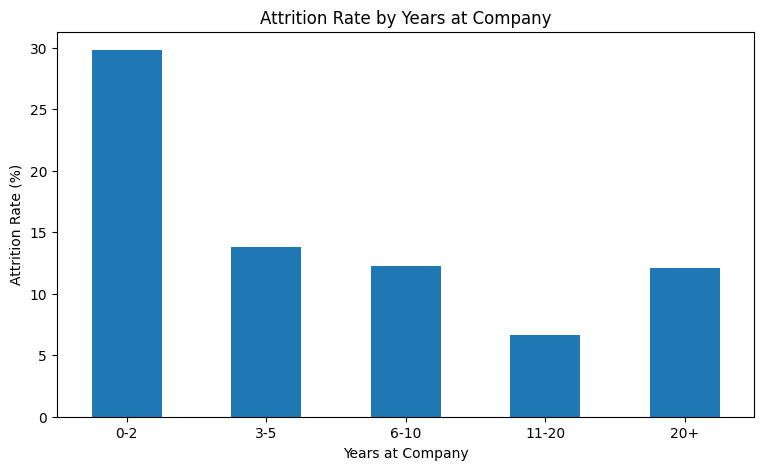

In [ ]:
bins = [0, 2, 5, 10, 20, 50]

labels = [
    '0-2',
    '3-5',
    '6-10',
    '11-20',
    '20+'
]

df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

tenure_attrition = pd.crosstab(
    df['TenureGroup'],
    df['Attrition'],
    normalize='index'
) * 100

print(tenure_attrition.round(2))

tenure_attrition['Yes'].plot(
    kind='bar',
    figsize=(9,5),
    title='Attrition Rate by Years at Company'
)

plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

## 18. Years at Company vs Monthly Income

A scatter plot was used to examine the relationship between years at the company and monthly income while differentiating employees based on attrition status.

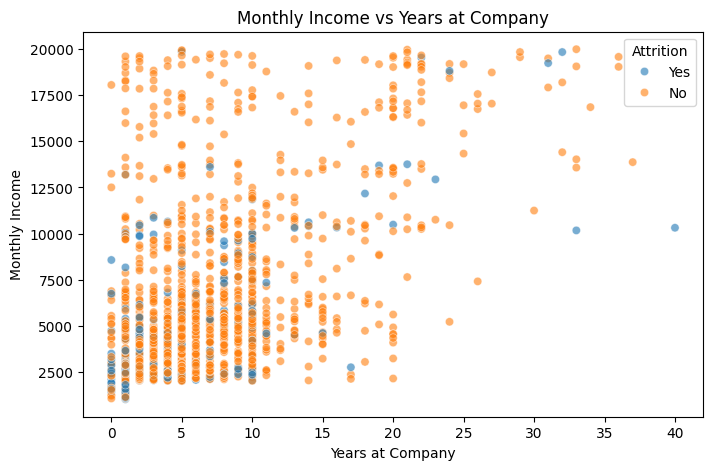

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='YearsAtCompany',
    y='MonthlyIncome',
    hue='Attrition',
    alpha=0.6
)

plt.title('Monthly Income vs Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Monthly Income')

plt.show()

## 19. Key Insights

- The dataset contains 1,470 employee records with no missing or duplicate records.
- Overall employee attrition is 16.12%.
- Sales has the highest department-level attrition at 20.63%.
- Sales Representatives show the highest job-role attrition at 39.76%.
- Employees working overtime show 30.53% attrition compared with 10.44% for employees without overtime.
- Job satisfaction level 1 has the highest attrition rate at 22.84%, while level 4 has 11.33%.
- Employees who left have a lower average monthly income of 4,787.09 compared with 6,832.74 for employees who stayed.
- Employees with 0–2 years at the company show the highest tenure-group attrition at 29.82%.

## 20. Recommendations

- Monitor attrition patterns in high-attrition job roles, particularly Sales Representatives.
- Review overtime requirements and workload distribution.
- Strengthen retention efforts for employees in their early years at the company.
- Monitor employee satisfaction levels and identify areas requiring improvement.
- Consider compensation, job role and tenure together when studying employee retention.

## 21. Conclusion

The Employee Attrition Analysis demonstrates how Exploratory Data Analysis can be used to understand workforce patterns.

The analysis covered data understanding, data cleaning, descriptive statistics, overall attrition, department and job-role comparisons, overtime, job satisfaction, monthly income and years at the company.

The findings provide a descriptive view of employee groups associated with different attrition patterns and can support further investigation into employee retention.

Overall, the project demonstrates the practical application of Python, Pandas and data visualization techniques to an HR analytics problem.